### N-Body Simulation with Mass Variation

**Contents**

* 1. Aim.
* 2. Significance.
* 3. Concepts and Methods.
* 4. Computational Method.
     * Defining a system.
     * Calculating Acceleration.
     * Calculating Energy.
     * Calculating Eccentricty.
     * Verlet Leap Frog Method.
     * Plotting Energy over timestep.
     * Plotting Eccentricity over timestep.


1.**AIM**:

*The aim of this project is to simulate a Sun-Earth-Mars and Earth's moon system and studying orbital trajectories of bodies and energy conservation due to variation in mass of sun.*

2.**Significance of this problem**.

One of the classic and interesting problem in area of physics is N Body Problem. It is applicable in many areas for instance celestial mechanics, the idea behind this problem is motion of bodies are govern by Netwonian Law of Gravitation,however due to addition of multiple bodies, the force of interaction from one body to another exhibits chaotic behavior that results in chaotic dynamics.

3.**Concept and Methods**

This project is made possible with the help of "Newtonian Mechanics" that governs the motion of astromical bodies and "Verlet Leap" frog integration method to update positions and velocities of bodies over time.

"Verlet Leap Frog Integration Method" is a numeical method that is applicable in solving compuational physics problem in areas of molecular dynamics, astrophysics. This method updates velocity at every half timestep and positions over every full timestep by using previous knowledge about initial position or acceleration and it is given by:

Updates the velocity to the half-step: $$ v \left(t +\frac{\Delta t}{2}\right ) = v(t)+\frac{a(t)\cdot\Delta t}{2} $$

Updates the position to the full step: $$ x\left(t + \Delta t\right) = x(t) + v \left( t + \frac{\Delta t}{2} \right) \cdot \Delta t $$

Updates the velocity to the full step: $$ v\left(t + \Delta t\right) = v \left( t + \frac{\Delta t}{2} \right) + \frac{a \left( t + \Delta t \right) \cdot 
\Delta t}{2} $$
where:
* x is position
* t is time
* v is velocity
* $\Delta t$ is change in time.

Verlet Leap frog is significantly important as it offers accuracy and stability for long term simulation and it is computational efficient.

*Newtonian Gravity states that any two bodies interacts through one another due to newtonian force of attraction, the force of attarction that one body exerts on another is proportional to masses of 2 bodies and inversely proportional to square of separation distance between them*.
The force of attarction is given by:
$$ F_{12} = \frac{G.M1.M2}{R_{12}^2}$$
where:
* $F_{12}$ is Force of attaraction.
* **M1** and *M2* are respective mass of body 1 and body 2
* **R** is the separation distance between Mass of bodies 1 and 2.
* **G** is Gravitational Constant that has a value of $6.67.10^{-11}Nm^2Kg{-2}$

4.**Computational Method**: The process of solving a physics problem and computational simulation requires to design a system and calculating forces, or interactions between bodies using numerical methods and simulating the results.

4.1**Defining System** : This part involves designing a system that are going to interact with one another like Sun,Earth,Moon and Mars.

In [1]:
from vpython import sphere, vector, rate, color, curve
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.67430e-11  # Gravitational constant (m^3 kg^-1 s^-2)
timestep = 3600  # 1 hour in seconds
simulation_time = 3 * 365 * 24 * timestep  # 3 years in seconds
steps = int(simulation_time / timestep)

# defining Class of our body
class Body:
    def __init__(self, name, mass, position, velocity, radius, color):
        self.name = name
        self.mass = mass
        self.position = vector(*position)
        self.velocity = vector(*velocity)
        self.radius = radius
        self.color = color
        self.object = sphere(pos=self.position, radius=self.radius, color=self.color, make_trail=True)
        
    def update_position(self):
        self.object.pos = self.position
        
# Creating Instances 
sun = Body("Sun", 1.989e30, [0, 0, 0], [0, 0, 0], 2e10, color.yellow)
earth = Body("Earth", 5.972e24, [1.496e11, 0, 0], [0, 29780, 0], 6e9, color.blue)
mars = Body("Mars", 6.39e23, [2.279e11, 0, 0], [0, 24100, 0], 4e9, color.red)
moon = Body("Moon", 7.34767309e22, [1.496e11 + 3.844e8, 0, 0], [0, 29780 + 1022, 0], 1e9, color.white)

bodies = [sun, earth, mars, moon]

<IPython.core.display.Javascript object>

**Calculating Acceleration**: This is a crucial step for updating postion and velocity,and even offeres numerical stability.

Acceleration of a body is derived from Newton's second law of motion, and Newtons force of Gravitation.

Newton's Second Law of Motion: Total force on a body i with mass Mi is given by:
$$\sum \vec F_{i} = M_{i} . \vec A_{i} $$

Force of Gravitation on body i from body j is given by:
$$ \mathbf{F}_{ij} = G \frac{M_i M_j}{|\mathbf{R}_j - \mathbf{R}i|^2} \hat{\mathbf{R}}{ij} $$

From Newtonian Gravity and Newton's second law of motion, acceleration **$\vec A$** of a body i with mass M1 is given by:

$$ \vec A_{i} = \frac{G.M_{j}.\hat R}{|\mathbf{R}_j - \mathbf{R}i|^3} $$

where:
* $\vec A$ is acceleration
* G is gravitational constant
* M is mass
* $\vec R$
* R is a magnitude of a position vector.
* and force on body $i\neq j$


In [2]:
def calculate_acceleration(bodies):
    accelerations = []
    for i, body1 in enumerate(bodies):
        acc = vector(0, 0, 0)
        for j, body2 in enumerate(bodies):
            if i != j:
                r_vec = body2.position - body1.position
                r = np.linalg.norm([r_vec.x, r_vec.y, r_vec.z])
                if r == 0:
                    continue
                acc += G * body2.mass * r_vec / r**3
        accelerations.append(acc)
    return accelerations

4.2**Energy Calculation for conservation of energy.**

Conservation of Energy: In an isolated system the total energy of system remains remains unchanged or constant over time. Energy can neither be created nor destroyed,but it can only be transformed from one form of energy to another.

In Celestial Mechnanics, the sum of Kinetic and Potential energy remains constant over time if there is no change in the system.

Kinetic Energy which is energy of a body due to its motion is given by:
$$ K_{E} = \frac{M.V^2}{2}$$

where:
* $K_{E}$ is Kinetic Energy.
* M is mass of a body.
* V is velocity of a body.
 

Potential Energy which is due to gravitational force of attraction is given by:
$$ - P_{E} = \frac{G.M_{1}.M_{2}}{R} $$

* G is Gravitational Constant.
* M1 and M2 are masses of different bodies.
* R is separation distance between 2 bodies.

The Sum of Kitentic and Potential Energy in a isolated systemthat follows law of conservation is given by:
$$ \sum_{i = 0}^{N} {K}_{i} + \sum_{i = 0}^{N} {P}_{i} = Constant $$

In [3]:
def calculate_energy(body, bodies):
    K = 0.5 * body.mass * np.linalg.norm([body.velocity.x, body.velocity.y, body.velocity.z])**2
    U = 0
    for other_body in bodies:
        if body != other_body:
            r_vec = other_body.position - body.position
            r = np.linalg.norm([r_vec.x, r_vec.y, r_vec.z])
            U -= G * body.mass * other_body.mass / r
    return K + U

def calculate_total_energy(bodies):
    total_energy = 0
    for body in bodies:
        total_energy += calculate_energy(body, bodies)
    return total_energy

4.3 **Eccentricity**

EEccentricity(e) defines the deviation of an orbital path from a circular shape for bodies orbiting around massive objects, such as the Sun." and it is given by:

$$ e = \sqrt{1+\frac{(2.E.L^2)}{\mu.(G.M1.M2)^2}}$$
where: 
* E is Energy is the total energy of system.
* L is angular momentum
* G is gravitational constant
* M1 and M2 are masses
* $\mu$ is combined mass(M1 and M2) 

Force of attraction influences angular momentum of a system, and total energy of a system. The value of total energy of a system determines the orbital eccentricity of a planet. If the orbital energy(total energy) is lower it results circular orbit and if orbital energy(total energy) is higher it results in elliptical/eccentric parth. 

for $e = 0$ mean the orbit is circular,

for e that lies between $0<e<1$ the orbit is elliptical



In [4]:
def calculate_eccentricity(body, bodies):
    L = np.linalg.norm(np.cross([body.position.x, body.position.y, body.position.z],
                                [body.velocity.x * body.mass, body.velocity.y * body.mass, body.velocity.z * body.mass]))
    E = calculate_energy(body, bodies)
    mu = sum(other_body.mass for other_body in bodies) - body.mass
    e = np.sqrt(1 + (2 * E * L**2) / (mu* (G * body.mass * sun.mass)**2))
    return e

4.4 **Simulation Using Verlet Leap Frog**

This Simulates motion of bodies for given timestep and even records the results for eccentricity and total energy during simulations. This algorithm calculates acceleration first and later updates position and velocities at every timesteps for 3 years using updated acceleration.

In [5]:
def simulate(bodies, steps, timestep):
    trail_curves = {body.name: curve(color=body.color) for body in bodies}
    eccentricities = {body.name: [] for body in bodies if body.name != "Sun"}
    total_energies = []

    # Initialize velocities using half-step acceleration
    initial_accelerations = calculate_acceleration(bodies)
    for i, body in enumerate(bodies):
        body.velocity += initial_accelerations[i] * (0.5 * timestep)

    for step in range(steps):
        # Update Sun's mass over time (e.g., losing 0.1% of its mass every year)
        sun.mass *= (1 - 0.1 / (365 * 24 * (3600 / timestep)))
        
        # Update positions using the half-step velocities
        for i, body in enumerate(bodies):
            body.position += body.velocity * timestep
            body.update_position()
            trail_curves[body.name].append(pos=body.position)

        # Calculate new accelerations after updating positions
        new_accelerations = calculate_acceleration(bodies)

        # Update velocities using the average of current and new accelerations
        for i, body in enumerate(bodies):
            body.velocity += new_accelerations[i] * timestep

        for body in bodies:
            if body.name != "Sun":
                eccentricities[body.name].append(calculate_eccentricity(body, bodies))

        # Calculate and store total energy
        total_energy = calculate_total_energy(bodies)
        total_energies.append(total_energy)

        rate(400)

    return eccentricities, total_energies

eccentricities, total_energies = simulate(bodies, steps, timestep)

4.5 **Plotting Eccentricity Over Time-Steps**

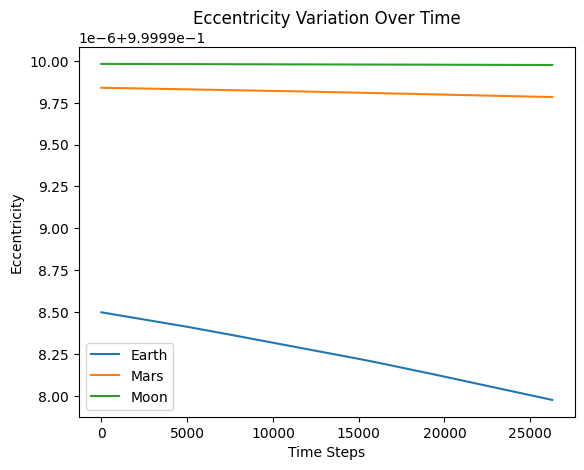

In [6]:
# Plotting the eccentricities
for body, ecc in eccentricities.items():
    plt.plot(ecc, label=body)

plt.xlabel('Time Steps')
plt.ylabel('Eccentricity')
plt.title('Eccentricity Variation Over Time')
plt.legend()
plt.show()

Eccentricity of Moon is constant however, Earth significantly losses it's eccentricity and there is a slight loss in eccentricity of Mars as well.This loss are result of change in orbital energy and angular momentum of a system caused by loss of mass of sun. 

4.6 **Plotting Total Energies**

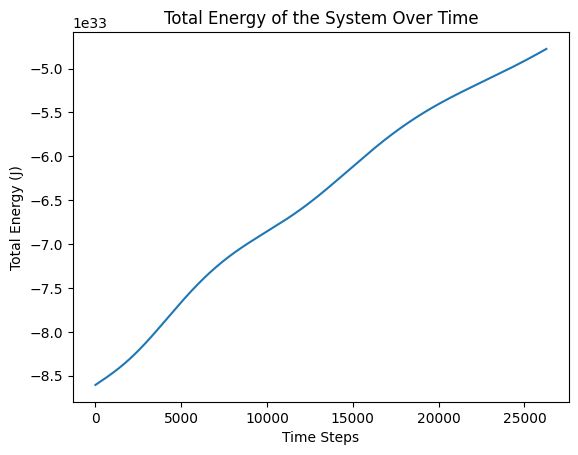

In [7]:
# Plotting the total energy
plt.plot(total_energies)
plt.xlabel('Time Steps')
plt.ylabel('Total Energy (J)')
plt.title('Total Energy of the System Over Time')
plt.show()

The Total Energy of our system is not conserved as the energy of system is not constant, it is increasing as the Sun losses it's mass by 0.01% every year.
This voilates the energy conservation of system.